Data Preparation

In [3]:
from google.colab import files

print("Please upload the 'q2_customers.csv' file:")
uploaded = files.upload()

Please upload the 'q2_customers.csv' file:


Saving q2_customers.csv to q2_customers (1).csv


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("q2_customers.csv")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled[:5]  # preview scaled data


array([[-0.72521859, -0.17615043,  0.11016555, -0.26501121, -0.0899507 ,
         0.55095233],
       [-1.48846049, -1.04682639,  0.48615719, -0.9804657 , -0.83517593,
        -0.68068477],
       [ 0.17679458,  0.2673371 , -0.45382191, -0.23685064, -0.67404615,
        -0.27013907],
       [-0.72521859, -1.01230889,  0.29816137, -0.82778261, -0.99630571,
        -1.09123047],
       [-1.48846049, -1.03448783,  1.42613628, -1.00598621, -0.65390493,
        -1.50177617]])

Choosing K — Elbow Method

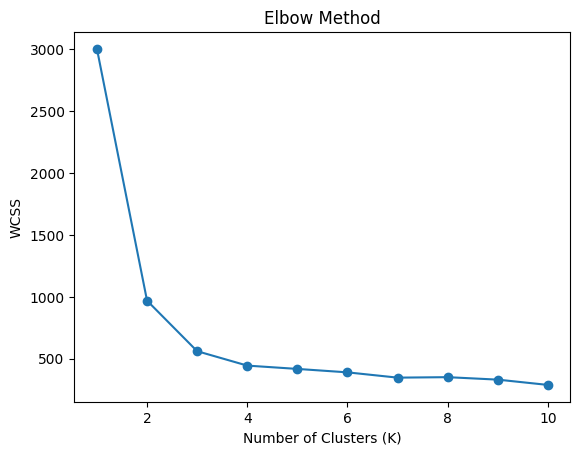

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


K-Means Clustering

In [6]:
# Fit KMeans with chosen K
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Cluster centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)
centroids


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.134146,89778.451220,2.463415,5345.500000,147.060976,7.524390
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.409639,89052.614458,2.590361,5713.361446,64.156627,7.506024


Dimensionality Reduction with PCA

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=["PC1", "PC2"]
)
loadings


Explained Variance Ratio: [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


Cluster Visualisation

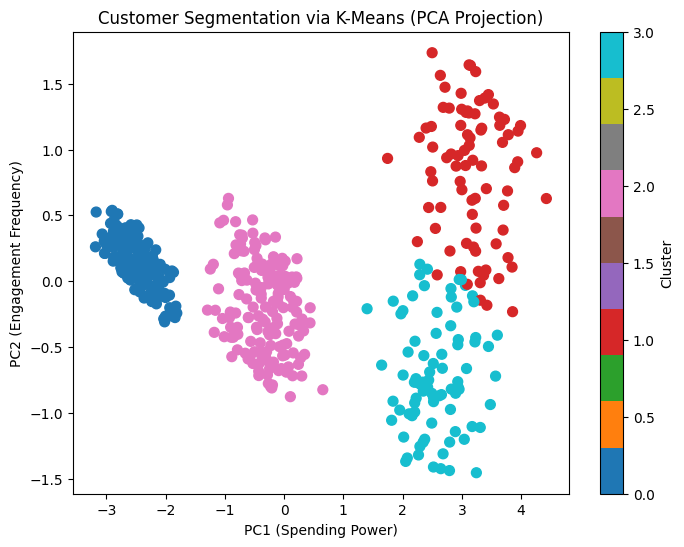

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["cluster"], cmap="tab10", s=50)
plt.xlabel("PC1 (Spending Power)")
plt.ylabel("PC2 (Engagement Frequency)")
plt.title("Customer Segmentation via K-Means (PCA Projection)")
plt.colorbar(label="Cluster")
plt.show()
